# Домашнее задание к семинарам 08-09 (HW08-09)
## Тема: PyTorch 101 b основы оптимизации обучения. Часть S08: MLP b регуляризация (Dropout, BatchNorm, EarlyStopping). Часть S09: learning rate диагностика, Adam vs SGD+momentum, weight decay.

### Импорт библиотек и настройка воспроизводимости, device (CUDA)

In [87]:
# Базовые библиотеки
import os
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# PyTorch(vision) для работы с данными
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


In [61]:
def set_seed(seed: int = 312) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 312
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


### Импорт датасета KMNIST, sanity-check

In [62]:
# нормализация задаётся как для одноканальных изображений
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [63]:
# тренировочный датасет
train_full = torchvision.datasets.EMNIST(
    root='./data', train=True, download=True, transform=transform, split="balanced"
)

# тестовый датасет
test_ds = torchvision.datasets.EMNIST(
    root='./data', train=False, download=True, transform=transform, split="balanced"
)

In [64]:
BATCH_SIZE = 512 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 4
val_size = int(0.2 * len(train_full))
train_size = len(train_full) - val_size

generator = torch.Generator().manual_seed(SEED)


train_subset, val_subset = random_split(
    train_full, [train_size, val_size], generator=generator
)
train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_subset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

# Проверка
# Проверка (sanity check)
print(f"Train size: {len(train_subset)}")
print(f"Val size: {len(val_subset)}")
print(f"Test size: {len(test_ds)}")
print(f"Число классов: {len(train_full.classes)}")
print(f"Пример батча: {next(iter(train_loader))[0].shape}")

# Берём один батч для проверки
x_batch, y_batch = next(iter(train_loader))
print(f"\nРазмерность x_batch: {x_batch.shape}")
print(f"Размерность y_batch: {y_batch.shape}")
print(f"Тип данных x_batch: {x_batch.dtype}")
print(f"Тип данных of y_batch: {y_batch.dtype}")
print(f"Min x_batch: {x_batch.min().item():.4f}")
print(f"Max x_batch: {x_batch.max().item():.4f}")
print(f"Классы y_batch: {torch.unique(y_batch)}")

Train size: 90240
Val size: 22560
Test size: 18800
Число классов: 47
Пример батча: torch.Size([512, 1, 28, 28])

Размерность x_batch: torch.Size([512, 1, 28, 28])
Размерность y_batch: torch.Size([512])
Тип данных x_batch: torch.float32
Тип данных of y_batch: torch.int64
Min x_batch: -1.0000
Max x_batch: 1.0000
Классы y_batch: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46])


### Реализация MLP и цикла обучения

In [65]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: typle = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False
    ):
        super().__init__()

        # допустимые функции активации
        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Неизвестная функция активации: {activation}")

        # превращение изображения в простой вектор пикселей
        layers = [nn.Flatten()]

        # последовательность слоёв сети
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [66]:
# Accuracy для классификации: logits -> argmax -> сравнение с y_true
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

# итерация обучения батча
def train_one_epoch(model, loader, optimizer, criterion, device):
    # train-режим (Dropout/BatchNorm)
    model.train()  
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # обнуление градиента
        optimizer.zero_grad(set_to_none=True)

        # предсказания модели
        logits = model(x)
        # ошибка предсказаний
        loss = criterion(logits, y)

        # оптимизация по градиенту
        loss.backward()
        optimizer.step()

        # обновление общей ошибки
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


# валидация
@torch.no_grad() 
def evaluate(model, loader, criterion, device):
    # eval-режим (Dropout/BatchNorm)
    model.eval()  
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # ошибка предсказаний на одном объекте
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

# Основной цикл обучения с логированием истории
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        start_time = time.time()
        
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        epoch_time = time.time() - start_time
        
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f} | "
                f"time={epoch_time:.1f}s"
            )

    return history

In [67]:
# быстрая проверка модели
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
x_batch, _ = next(iter(train_loader))
with torch.no_grad():
    out = model(x_batch.to(device))
print(f"Выход модели для батча: {out.shape}") 

Выход модели для батча: torch.Size([512, 47])


In [68]:
# loss и оптимизатор
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# запуск обучения
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=10,
    verbose=True
)

epoch 01/10 | train loss=1.6688, acc=0.5970 | val loss=0.9096, acc=0.7389 | time=26.0s
epoch 02/10 | train loss=0.8626, acc=0.7435 | val loss=0.6718, acc=0.7930 | time=25.7s
epoch 03/10 | train loss=0.7078, acc=0.7775 | val loss=0.5716, acc=0.8130 | time=25.9s
epoch 04/10 | train loss=0.6349, acc=0.7950 | val loss=0.5286, acc=0.8259 | time=25.4s
epoch 05/10 | train loss=0.5869, acc=0.8067 | val loss=0.5008, acc=0.8336 | time=26.2s
epoch 06/10 | train loss=0.5583, acc=0.8139 | val loss=0.4843, acc=0.8377 | time=25.5s
epoch 07/10 | train loss=0.5365, acc=0.8204 | val loss=0.4656, acc=0.8435 | time=26.4s
epoch 08/10 | train loss=0.5126, acc=0.8265 | val loss=0.4614, acc=0.8428 | time=25.7s
epoch 09/10 | train loss=0.4977, acc=0.8308 | val loss=0.4644, acc=0.8432 | time=26.0s
epoch 10/10 | train loss=0.4846, acc=0.8351 | val loss=0.4453, acc=0.8451 | time=25.5s


### Общие настройки для экспериментов

In [71]:
EPOCHS = 6
LR = 2e-3

# Фиксируем seed перед каждым экспериментом для воспроизводимости
def reset_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

### E1: Baseline (без регуляризации)

In [72]:
print("=== E1: Baseline (no dropout, no batchnorm) ===")
set_seed(SEED)

model_e1 = MLP(
    hidden_dims=(512, 256, 128),  # побольше слоёв для переобучения
    dropout_p=0.0,
    use_batchnorm=False
).to(device)
model_e1.apply(reset_weights)

optimizer = optim.Adam(model_e1.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

history_e1 = fit(
    model=model_e1,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    verbose=True
)

best_val_acc_e1 = max(history_e1['val_acc'])
best_epoch_e1 = np.argmax(history_e1['val_acc']) + 1
print(f"Best val accuracy: {best_val_acc_e1:.4f} at epoch {best_epoch_e1}")

=== E1: Baseline (no dropout, no batchnorm) ===
epoch 01/6 | train loss=1.4638, acc=0.5882 | val loss=0.8592, acc=0.7349 | time=25.4s
epoch 02/6 | train loss=0.7352, acc=0.7689 | val loss=0.6662, acc=0.7854 | time=25.8s
epoch 03/6 | train loss=0.5936, acc=0.8057 | val loss=0.6002, acc=0.8020 | time=24.8s
epoch 04/6 | train loss=0.5187, acc=0.8257 | val loss=0.5721, acc=0.8090 | time=26.0s
epoch 05/6 | train loss=0.4746, acc=0.8383 | val loss=0.5652, acc=0.8138 | time=26.0s
epoch 06/6 | train loss=0.4394, acc=0.8472 | val loss=0.5431, acc=0.8222 | time=25.7s
Best val accuracy: 0.8222 at epoch 6


### E2: Dropout

In [73]:
print("\n=== E2: Dropout (p=0.3) ===")
set_seed(SEED)

model_e2 = MLP(
    hidden_dims=(512, 256, 128),
    dropout_p=0.3,
    use_batchnorm=False
).to(device)
model_e2.apply(reset_weights)

optimizer = optim.Adam(model_e2.parameters(), lr=LR)

history_e2 = fit(
    model=model_e2,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    verbose=True
)

best_val_acc_e2 = max(history_e2['val_acc'])
best_epoch_e2 = np.argmax(history_e2['val_acc']) + 1
print(f"Best val accuracy: {best_val_acc_e2:.4f} at epoch {best_epoch_e2}")


=== E2: Dropout (p=0.3) ===
epoch 01/6 | train loss=2.3468, acc=0.3576 | val loss=1.0643, acc=0.6799 | time=25.4s
epoch 02/6 | train loss=1.2846, acc=0.6168 | val loss=0.8183, acc=0.7420 | time=25.4s
epoch 03/6 | train loss=1.0857, acc=0.6689 | val loss=0.7096, acc=0.7684 | time=25.0s
epoch 04/6 | train loss=0.9767, acc=0.6992 | val loss=0.6681, acc=0.7804 | time=24.8s
epoch 05/6 | train loss=0.9125, acc=0.7157 | val loss=0.6312, acc=0.7916 | time=25.1s
epoch 06/6 | train loss=0.8608, acc=0.7314 | val loss=0.6024, acc=0.8009 | time=24.2s
Best val accuracy: 0.8009 at epoch 6


### E3: BatchNorm

In [74]:
print("\n=== E3: BatchNorm ===")
set_seed(SEED)

model_e3 = MLP(
    hidden_dims=(512, 256, 128),
    dropout_p=0.0,
    use_batchnorm=True
).to(device)
model_e3.apply(reset_weights)

optimizer = optim.Adam(model_e3.parameters(), lr=LR)

history_e3 = fit(
    model=model_e3,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    verbose=True
)

best_val_acc_e3 = max(history_e3['val_acc'])
best_epoch_e3 = np.argmax(history_e3['val_acc']) + 1
print(f"Best val accuracy: {best_val_acc_e3:.4f} at epoch {best_epoch_e3}")


=== E3: BatchNorm ===
epoch 01/6 | train loss=0.9868, acc=0.7220 | val loss=0.6609, acc=0.7891 | time=24.6s
epoch 02/6 | train loss=0.5039, acc=0.8328 | val loss=0.5346, acc=0.8252 | time=25.6s
epoch 03/6 | train loss=0.4071, acc=0.8587 | val loss=0.4972, acc=0.8322 | time=26.0s
epoch 04/6 | train loss=0.3510, acc=0.8744 | val loss=0.4892, acc=0.8334 | time=26.1s
epoch 05/6 | train loss=0.3109, acc=0.8856 | val loss=0.5028, acc=0.8340 | time=25.2s
epoch 06/6 | train loss=0.2828, acc=0.8934 | val loss=0.4851, acc=0.8375 | time=25.3s
Best val accuracy: 0.8375 at epoch 6


### Выбор лучшей модели (E2 vs E3)

In [75]:
# Сравниваем по лучшей валидационной точности
if best_val_acc_e2 >= best_val_acc_e3:
    print(f"\nВыбран Dropout (val_acc={best_val_acc_e2:.4f})")
    best_config = {
        'dropout_p': 0.3,
        'use_batchnorm': False,
        'name': 'dropout'
    }
else:
    print(f"\nВыбран BatchNorm (val_acc={best_val_acc_e3:.4f})")
    best_config = {
        'dropout_p': 0.0,
        'use_batchnorm': True,
        'name': 'batchnorm'
    }


Выбран BatchNorm (val_acc=0.8375)


### E4: EarlyStopping на лучшей модели

In [76]:
print(f"\n=== E4: EarlyStopping на {best_config['name']} (patience=4) ===")
set_seed(SEED)

# Класс EarlyStopping
class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.best_state = None
    
    def step(self, val_acc, model):
        if self.best_score is None:
            self.best_score = val_acc
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        
        if val_acc > self.best_score + self.min_delta:
            self.best_score = val_acc
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience
    
    def restore_best(self, model):
        model.load_state_dict(self.best_state)

# Создаём модель с лучшей конфигурацией
model_e4 = MLP(
    hidden_dims=(512, 256, 128),
    dropout_p=best_config['dropout_p'],
    use_batchnorm=best_config['use_batchnorm']
).to(device)
model_e4.apply(reset_weights)

optimizer = optim.Adam(model_e4.parameters(), lr=LR)

# Обучение с EarlyStopping
early_stopping = EarlyStopping(patience=4, min_delta=0.001)
history_e4 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    
    tr_loss, tr_acc = train_one_epoch(model_e4, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model_e4, val_loader, criterion, device)
    
    epoch_time = time.time() - start_time
    
    history_e4["train_loss"].append(tr_loss)
    history_e4["train_acc"].append(tr_acc)
    history_e4["val_loss"].append(va_loss)
    history_e4["val_acc"].append(va_acc)
    
    print(
        f"epoch {epoch:02d}/{EPOCHS} | "
        f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
        f"val loss={va_loss:.4f}, acc={va_acc:.4f} | "
        f"time={epoch_time:.1f}s"
    )
    
    if early_stopping.step(va_acc, model_e4):
        print(f"Early stopping triggered at epoch {epoch}")
        early_stopping.restore_best(model_e4)
        break

# Сохраняем лучшую модель
torch.save(model_e4.state_dict(), "artifacts/best_model.pt")
print("Лучшая модель сохранена как best_model.pt")
best_val_acc_e4 = early_stopping.best_score
print(f"Best val accuracy with early stopping: {best_val_acc_e4:.4f}")


=== E4: EarlyStopping на batchnorm (patience=4) ===
epoch 01/6 | train loss=0.9868, acc=0.7220 | val loss=0.6609, acc=0.7891 | time=25.4s
epoch 02/6 | train loss=0.5039, acc=0.8328 | val loss=0.5346, acc=0.8252 | time=24.9s
epoch 03/6 | train loss=0.4071, acc=0.8587 | val loss=0.4972, acc=0.8322 | time=24.5s
epoch 04/6 | train loss=0.3510, acc=0.8744 | val loss=0.4892, acc=0.8334 | time=24.7s
epoch 05/6 | train loss=0.3109, acc=0.8856 | val loss=0.5028, acc=0.8340 | time=24.6s
epoch 06/6 | train loss=0.2828, acc=0.8934 | val loss=0.4851, acc=0.8375 | time=25.1s
Лучшая модель сохранена как best_model.pt
Best val accuracy with early stopping: 0.8375


In [77]:
print("\n=== Финальная оценка на test ===")
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}, test accuracy: {test_acc:.4f}")


=== Финальная оценка на test ===
Test loss: 0.5067, test accuracy: 0.8352


### Визуализация сравнения

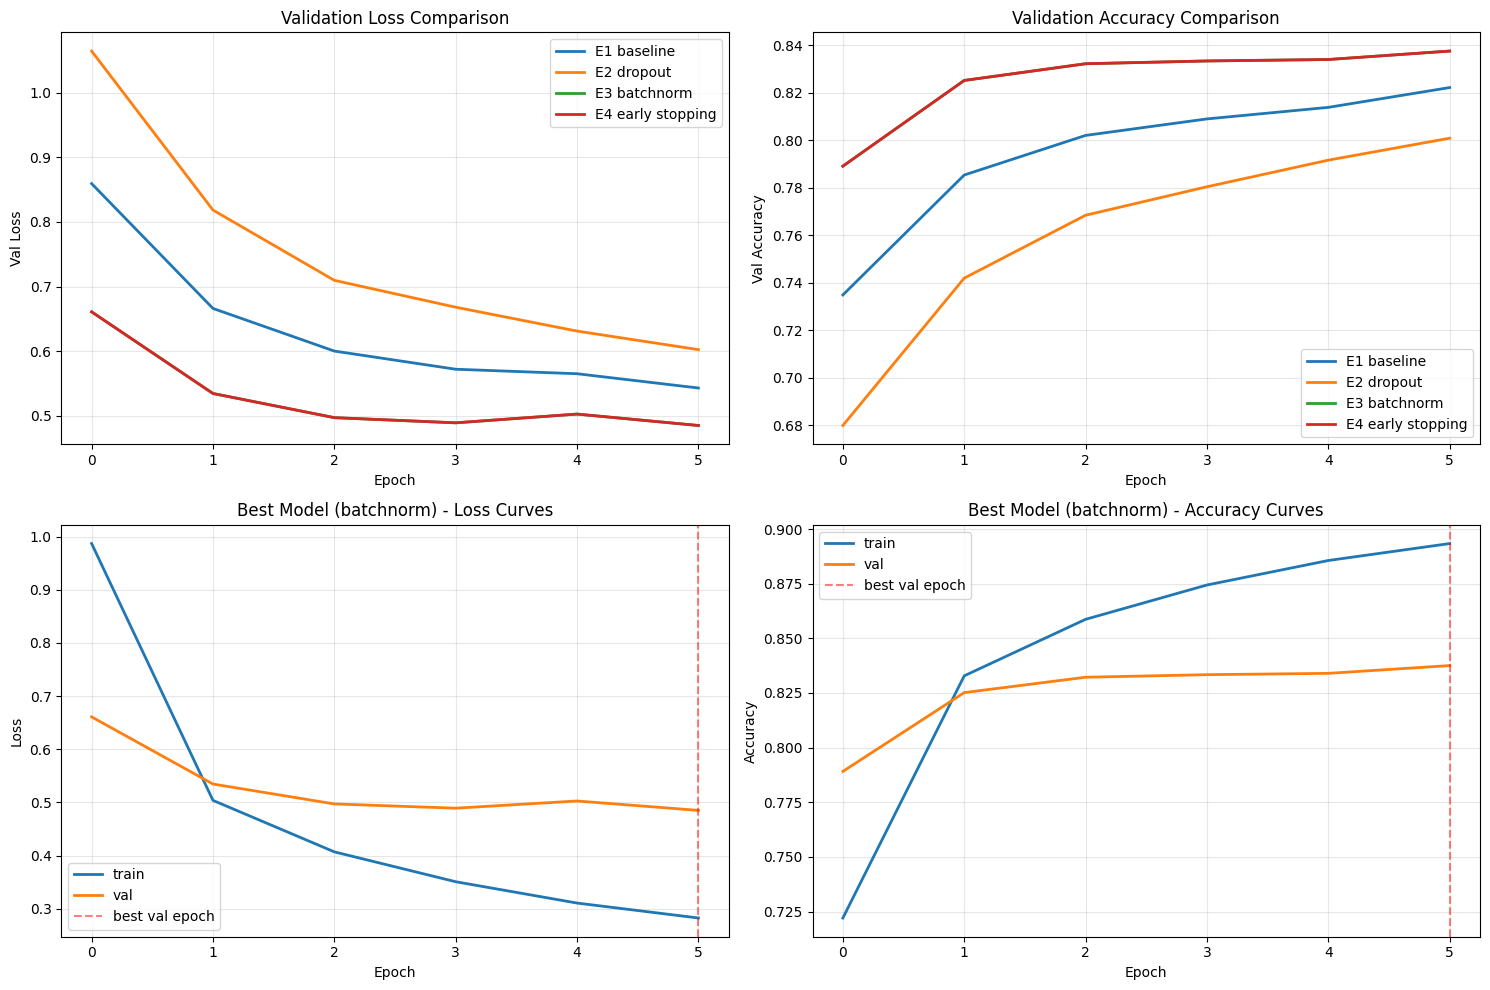

In [91]:
plt.figure(figsize=(15, 10))

# Loss
plt.subplot(2, 2, 1)
plt.plot(history_e1['val_loss'], label='E1 baseline', linewidth=2)
plt.plot(history_e2['val_loss'], label='E2 dropout', linewidth=2)
plt.plot(history_e3['val_loss'], label='E3 batchnorm', linewidth=2)
plt.plot(history_e4['val_loss'], label='E4 early stopping', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.legend()
plt.title('Validation Loss Comparison')
plt.grid(True, alpha=0.3)

# Accuracy
plt.subplot(2, 2, 2)
plt.plot(history_e1['val_acc'], label='E1 baseline', linewidth=2)
plt.plot(history_e2['val_acc'], label='E2 dropout', linewidth=2)
plt.plot(history_e3['val_acc'], label='E3 batchnorm', linewidth=2)
plt.plot(history_e4['val_acc'], label='E4 early stopping', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.title('Validation Accuracy Comparison')
plt.grid(True, alpha=0.3)

# Train vs Val для лучшей модели
plt.subplot(2, 2, 3)
plt.plot(history_e4['train_loss'], label='train', linewidth=2)
plt.plot(history_e4['val_loss'], label='val', linewidth=2)
plt.axvline(x=np.argmax(history_e4['val_acc']), color='r', linestyle='--', alpha=0.5, label='best val epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title(f'Best Model ({best_config["name"]}) - Loss Curves')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(history_e4['train_acc'], label='train', linewidth=2)
plt.plot(history_e4['val_acc'], label='val', linewidth=2)
plt.axvline(x=np.argmax(history_e4['val_acc']), color='r', linestyle='--', alpha=0.5, label='best val epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title(f'Best Model ({best_config["name"]}) - Accuracy Curves')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png', dpi=150, bbox_inches='tight')
plt.show()

### Эксперименты O1-O3

In [82]:
# Используем архитектуру как в E4 (из best_config)
base_architecture = {
    'hidden_dims': (512, 256, 128),
    'dropout_p': best_config['dropout_p'],
    'use_batchnorm': best_config['use_batchnorm']
}

# -------------------- O1: Слишком большой LR --------------------
print("\n=== O1: Learning Rate too high (lr=0.1) ===")
set_seed(SEED)

model_o1 = MLP(**base_architecture).to(device)
model_o1.apply(reset_weights)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=0.1)

history_o1 = fit(
    model=model_o1,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_o1,
    criterion=criterion,
    device=device,
    epochs=8,  # достаточно для демонстрации проблемы
    verbose=True
)

# -------------------- O2: Слишком маленький LR --------------------
print("\n=== O2: Learning Rate too low (lr=1e-6) ===")
set_seed(SEED)

model_o2 = MLP(**base_architecture).to(device)
model_o2.apply(reset_weights)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-6)

history_o2 = fit(
    model=model_o2,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_o2,
    criterion=criterion,
    device=device,
    epochs=8,
    verbose=True
)

# -------------------- O3: SGD + momentum + weight decay --------------------
print("\n=== O3: SGD + momentum (0.9) + weight decay (1e-4) ===")
set_seed(SEED)

model_o3 = MLP(**base_architecture).to(device)
model_o3.apply(reset_weights)

optimizer_o3 = optim.SGD(
    model_o3.parameters(), 
    lr=1e-2,  # разумный LR для SGD
    momentum=0.9,
    weight_decay=1e-4
)

history_o3 = fit(
    model=model_o3,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_o3,
    criterion=criterion,
    device=device,
    epochs=12,  # чуть больше, так как SGD медленнее
    verbose=True
)


=== O1: Learning Rate too high (lr=0.1) ===
epoch 01/8 | train loss=1.0384, acc=0.6854 | val loss=0.7959, acc=0.7525 | time=30.2s
epoch 02/8 | train loss=0.6276, acc=0.7900 | val loss=0.6849, acc=0.7842 | time=29.9s
epoch 03/8 | train loss=0.5350, acc=0.8176 | val loss=0.6214, acc=0.8026 | time=29.8s
epoch 04/8 | train loss=0.4822, acc=0.8309 | val loss=0.5806, acc=0.8101 | time=29.7s
epoch 05/8 | train loss=0.4432, acc=0.8418 | val loss=0.5836, acc=0.8129 | time=29.5s
epoch 06/8 | train loss=0.4258, acc=0.8476 | val loss=0.5415, acc=0.8298 | time=29.8s
epoch 07/8 | train loss=0.4045, acc=0.8538 | val loss=0.5744, acc=0.8201 | time=30.2s
epoch 08/8 | train loss=0.3887, acc=0.8589 | val loss=0.5290, acc=0.8294 | time=29.3s

=== O2: Learning Rate too low (lr=1e-6) ===
epoch 01/8 | train loss=4.3723, acc=0.0198 | val loss=4.3205, acc=0.0228 | time=29.8s
epoch 02/8 | train loss=4.3022, acc=0.0233 | val loss=4.2529, acc=0.0266 | time=30.0s
epoch 03/8 | train loss=4.2329, acc=0.0270 | val l

### График для O1-O2-O3 (curves_lr_extremes.png)

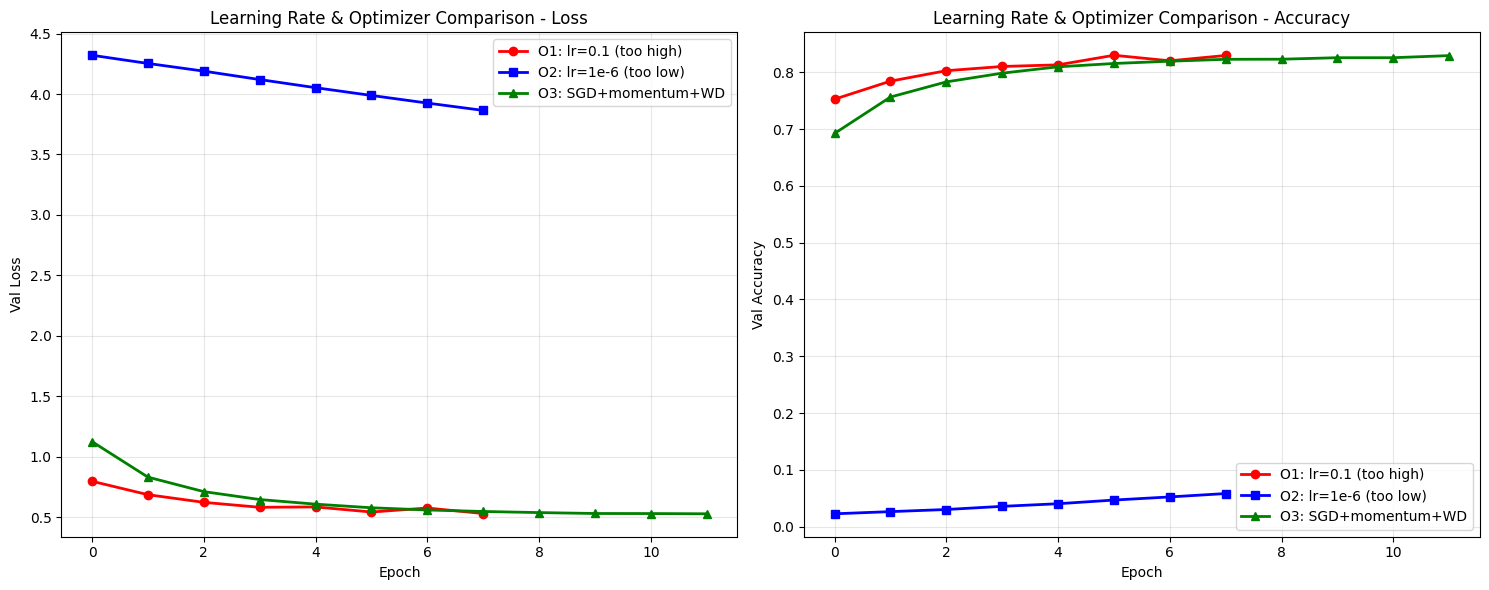

curves_lr_extremes.png сохранён в artifacts/figures/


In [84]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(history_o1['val_loss'], label='O1: lr=0.1 (too high)', linewidth=2, color='red', marker='o')
plt.plot(history_o2['val_loss'], label='O2: lr=1e-6 (too low)', linewidth=2, color='blue', marker='s')
plt.plot(history_o3['val_loss'], label='O3: SGD+momentum+WD', linewidth=2, color='green', marker='^')
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.legend()
plt.title('Learning Rate & Optimizer Comparison - Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_o1['val_acc'], label='O1: lr=0.1 (too high)', linewidth=2, color='red', marker='o')
plt.plot(history_o2['val_acc'], label='O2: lr=1e-6 (too low)', linewidth=2, color='blue', marker='s')
plt.plot(history_o3['val_acc'], label='O3: SGD+momentum+WD', linewidth=2, color='green', marker='^')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.title('Learning Rate & Optimizer Comparison - Accuracy')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=150, bbox_inches='tight')
plt.show()
print("curves_lr_extremes.png сохранён в artifacts/figures/")

### Сохранение результатов в CSV

In [85]:
Path("artifacts/figures").mkdir(parents=True, exist_ok=True)
results = []
o_results = []

# E1
best_epoch_e1 = np.argmax(history_e1['val_acc'])
results.append({
    'experiment_id': 'E1',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': '512-256-128, relu, dropout=0.0, batchnorm=False',
    'optimizer': 'Adam',
    'lr': LR,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(history_e1['val_acc']),
    'best_val_accuracy': history_e1['val_acc'][best_epoch_e1],
    'best_val_loss': history_e1['val_loss'][best_epoch_e1]
})

# E2
best_epoch_e2 = np.argmax(history_e2['val_acc'])
results.append({
    'experiment_id': 'E2',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': '512-256-128, relu, dropout=0.3, batchnorm=False',
    'optimizer': 'Adam',
    'lr': LR,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(history_e2['val_acc']),
    'best_val_accuracy': history_e2['val_acc'][best_epoch_e2],
    'best_val_loss': history_e2['val_loss'][best_epoch_e2]
})

# E3
best_epoch_e3 = np.argmax(history_e3['val_acc'])
results.append({
    'experiment_id': 'E3',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': '512-256-128, relu, dropout=0.0, batchnorm=True',
    'optimizer': 'Adam',
    'lr': LR,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(history_e3['val_acc']),
    'best_val_accuracy': history_e3['val_acc'][best_epoch_e3],
    'best_val_loss': history_e3['val_loss'][best_epoch_e3]
})

# E4
best_epoch_e4 = np.argmax(history_e4['val_acc'])
results.append({
    'experiment_id': 'E4',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': f"512-256-128, relu, dropout={best_config['dropout_p']}, batchnorm={best_config['use_batchnorm']}",
    'optimizer': 'Adam',
    'lr': LR,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(history_e4['val_acc']),
    'best_val_accuracy': history_e4['val_acc'][best_epoch_e4],
    'best_val_loss': history_e4['val_loss'][best_epoch_e4]
})

# O1
best_epoch_o1 = np.argmax(history_o1['val_acc'])
o_results.append({
    'experiment_id': 'O1',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': '512-256-128, relu, dropout=0.3, batchnorm=True',
    'optimizer': 'Adam',
    'lr': 0.1,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(history_o1['val_acc']),
    'best_val_accuracy': history_o1['val_acc'][best_epoch_o1],
    'best_val_loss': history_o1['val_loss'][best_epoch_o1]
})

# O2
best_epoch_o2 = np.argmax(history_o2['val_acc'])
o_results.append({
    'experiment_id': 'O2',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': '512-256-128, relu, dropout=0.3, batchnorm=True',
    'optimizer': 'Adam',
    'lr': 1e-6,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(history_o2['val_acc']),
    'best_val_accuracy': history_o2['val_acc'][best_epoch_o2],
    'best_val_loss': history_o2['val_loss'][best_epoch_o2]
})

# O3
best_epoch_o3 = np.argmax(history_o3['val_acc'])
o_results.append({
    'experiment_id': 'O3',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': '512-256-128, relu, dropout=0.3, batchnorm=True',
    'optimizer': 'SGD',
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 0.0001,
    'epochs_trained': len(history_o3['val_acc']),
    'best_val_accuracy': history_o3['val_acc'][best_epoch_o3],
    'best_val_loss': history_o3['val_loss'][best_epoch_o3]
})

# Объединяем и сохраняем
df = pd.DataFrame(results + o_results)
df.to_csv('artifacts/runs.csv', index=False)

print("\nРезультаты сохранены в artifacts/runs.csv")
print("\nСводная таблица:")
print(df.to_string(index=False))


Результаты сохранены в artifacts/runs.csv

Сводная таблица:
experiment_id dataset  seed                                   model_summary optimizer       lr momentum  weight_decay  epochs_trained  best_val_accuracy  best_val_loss
           E1  EMNIST   312 512-256-128, relu, dropout=0.0, batchnorm=False      Adam 0.002000                 0.0000               6           0.822179       0.543099
           E2  EMNIST   312 512-256-128, relu, dropout=0.3, batchnorm=False      Adam 0.002000                 0.0000               6           0.800868       0.602446
           E3  EMNIST   312  512-256-128, relu, dropout=0.0, batchnorm=True      Adam 0.002000                 0.0000               6           0.837543       0.485105
           E4  EMNIST   312  512-256-128, relu, dropout=0.0, batchnorm=True      Adam 0.002000                 0.0000               6           0.837543       0.485105
           O1  EMNIST   312  512-256-128, relu, dropout=0.3, batchnorm=True      Adam 0.100000     

### best_config.json

In [88]:
best_config_json = {
    'dataset': 'EMNIST',
    'seed': SEED,
    'model': {
        'hidden_dims': [512, 256, 128],
        'activation': 'relu',
        'dropout_p': best_config['dropout_p'],
        'use_batchnorm': best_config['use_batchnorm']
    },
    'training': {
        'optimizer': 'Adam',
        'lr': LR,
        'batch_size': BATCH_SIZE,
        'epochs_trained': len(history_e4['val_acc'])
    },
    'best_val_accuracy': float(best_val_acc_e4),
    'test_accuracy': float(test_acc)
}

with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config_json, f, indent=2)

print("best_config.json сохранён в artifacts/")

best_config.json сохранён в artifacts/
